# What is Transfer Learning?


Transfer learning is a machine learning technique where a model trained on one task is repurposed as the foundation for a second task. This approach is beneficial when the second task is related to the first or when data for the second task is limited.

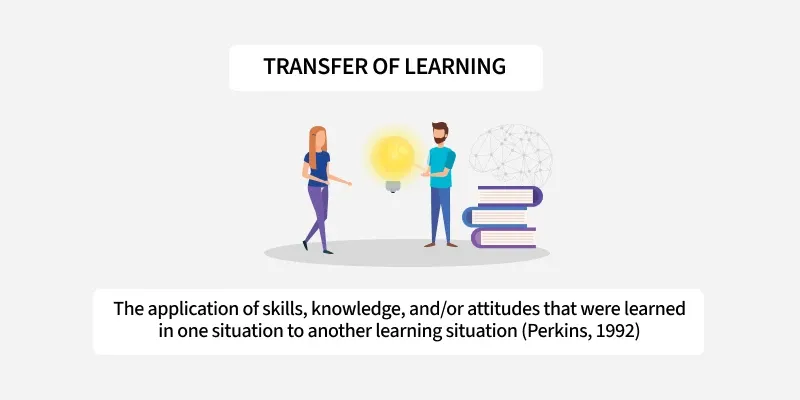

Using learned features from the initial task, the model can adapt more efficiently to the new task, accelerating learning and improving performance. Transfer learning also reduces the risk of overfitting, as the model already incorporates generalizable features useful for the second task.

## Importance of Transfer Learning

* **Limited Data:** Acquiring extensive labelled data is often challenging and costly. Transfer learning enables us to use pre-trained models, reducing the dependency on large datasets.
* **Enhanced Performance:** Starting with a pre-trained model which has already learned from substantial data allows for faster and more accurate results on new tasks ideal for applications needing high accuracy and efficiency.
* **Time and Cost Efficiency:** Transfer learning shortens training time and conserves resources by utilizing existing models hence eliminating the need for training from scratch.
* **Adaptability:** Models trained on one task can be fine-tuned for related tasks making transfer learning versatile for various applications from image recognition to natural language processing.

## Working of Transfer Learning

* **Pre-trained Model:** Start with a model already trained on a large dataset for a specific task. This pre-trained model has learned general features and patterns that are relevant across related tasks.
* **Base Model:** This pre-trained model, known as the base model, includes layers that have processed data to learn hierarchical representations, capturing low-level to complex features.
* **Transfer Layers:** Identify layers within the base model that hold generic information applicable to both the original and new tasks. These layers often near the top of the network capture broad, reusable features.
* **Fine-tuning:** Fine-tune these selected layers with data from the new task. This process helps retain the pre-trained knowledge while adjusting parameters to meet the specific requirements of the new task, improving accuracy and adaptability.

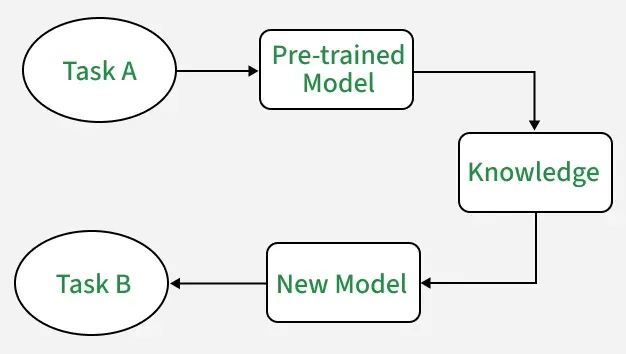

## Frozen Vs Trainable Layers in Transfer Learning

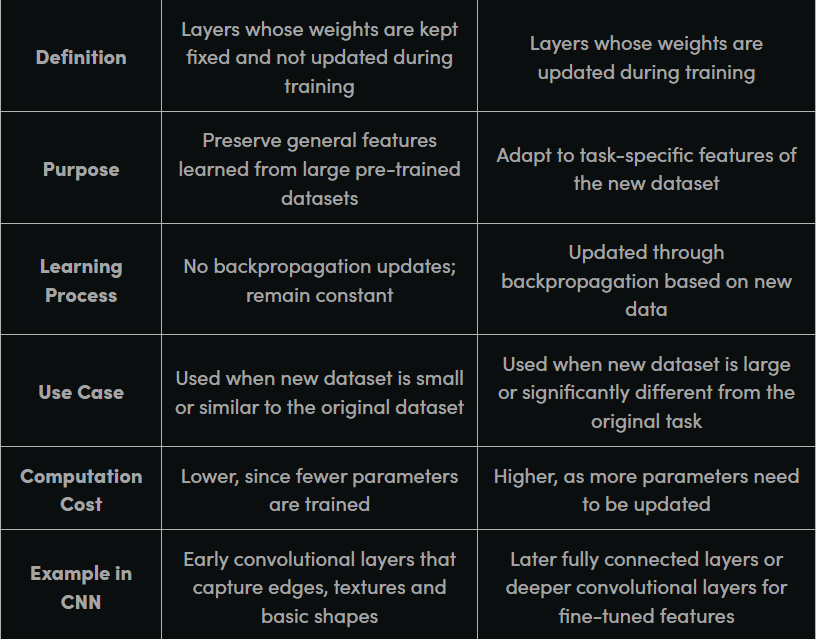

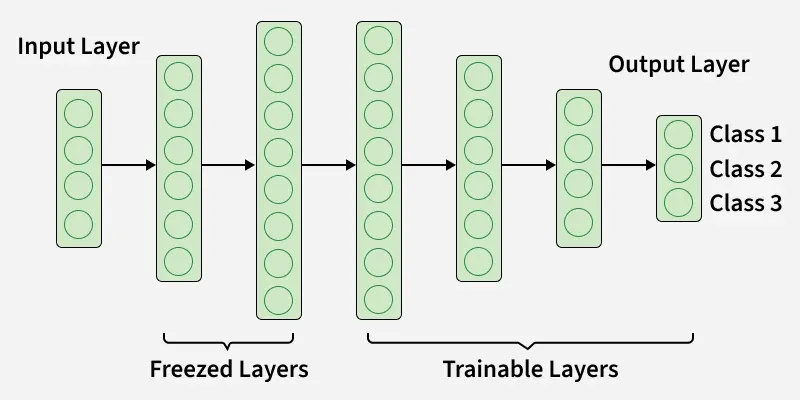

## How to Decide Which Layers to Freeze or Train?

The extent to which you freeze or fine-tune layers depends on the similarity and size of your target dataset:

* **Small, Similar Dataset:** For smaller datasets that resemble the original dataset, you freeze most layers and only fine-tune the last one or two layers to prevent overfitting.
* **Large, Similar Dataset:** With large, similar datasets you can unfreeze more layers allowing the model to adapt while retaining learned features from the base model.
* **Small, Different Dataset:** For smaller, dissimilar datasets, fine-tuning layers closer to the input layer helps the model learn task-specific features from scratch.
* **Large, Different Dataset:** In this case, fine-tuning the entire model helps the model adapt to the new task while using the broad knowledge from the pre-trained model.





## Transfer Learning with MobileNetV2 for MNIST Classification


Explore transfer learning by fine-tuning a MobileNetV2 model pre-trained on ImageNet for classifying MNIST digits.

### 1. Preparing the Dataset

* Reshape the images from grayscale (28x28, 1 channel) to RGB (28x28, 3 channels).
* Resize images to 32x32 pixels, aligning with our model’s configuration.
* Normalize pixel values to fall between 0 and 1 by dividing by 255.

In [7]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
import numpy as np

(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

train_images = np.stack([train_images] * 3, axis=-1)/255.0
test_images = np.stack([test_images] * 3, axis=-1)/255.0

train_images = tf.image.resize(train_images, [32, 32])
test_images = tf.image.resize(test_images, [32, 32])

train_labels = tf.keras.utils.to_categorical(train_labels, 10)
test_labels = tf.keras.utils.to_categorical(test_labels, 10)



## 2. Building the Model

We load MobileNetV2 with pre-trained weights from ImageNet excluding the fully connected top layers to customize for our 10-class classification task:

* Freeze the base model to retain learned features and avoid overfitting.
* Add a global average pooling layer to reduce model complexity.
* Add a dense layer with softmax activation for the output classes.

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Input, GlobalAveragePooling2D, Dense
from tensorflow.keras.models import Model

base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))
base_model.trainable = False  # Freeze base model

inputs = Input(shape=(32, 32, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
outputs = Dense(10, activation='softmax')(x)
model = Model(inputs, outputs)

C:\Users\PANDIT JI\AppData\Local\Temp\ipykernel_15024\3104373990.py:5: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(32, 32, 3))


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


### Compiling and Training the Mode

In [9]:
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics= ['accuracy'])
model.fit(train_images, train_labels, epochs=10, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 53s 33ms/step - accuracy: 0.4549 - loss: 1.8215 - val_accuracy: 0.6040 - val_loss: 1.2948
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 92s 39ms/step - accuracy: 0.6046 - loss: 1.2643 - val_accuracy: 0.6373 - val_loss: 1.1384
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 67s 29ms/step - accuracy: 0.6303 - loss: 1.1422 - val_accuracy: 0.6524 - val_loss: 1.0724
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 50s 34ms/step - accuracy: 0.6494 - loss: 1.0734 - val_accuracy: 0.6604 - val_loss: 1.0362
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 74s 28ms/step - accuracy: 0.6546 - loss: 1.0468 - val_accuracy: 0.6652 - val_loss: 1.0143
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 84s 29ms/step - accuracy: 0.6572 - loss: 1.0250 - val_accuracy: 0.6667 - val_loss: 1.0003
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 28ms/step - accuracy: 0.6603 - loss: 1.0117 - val_accuracy: 0.6694 - val_loss: 0.9902
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 45s 30ms/step - accuracy: 0.6672 -

### 4. Fine-Tuning the Model

In [ ]:
base_model.trainable = True  # Unfreeze base model for fine-tuning
for layer in base_model.layers[:100]:
    layer.trainable = False  # Freeze early layers

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=5, validation_split=0.2)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 115s 71ms/step - accuracy: 0.2287 - loss: 10.9412 - val_accuracy: 0.1374 - val_loss: 13.2536
Epoch 2/5
 948/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 66ms/step - accuracy: 0.4692 - loss: 2.6903

### 5. Model Evaluation

Once the model has been trained and fine-tuned we evaluate it on the test set, measuring its loss and accuracy. This step assesses how well the transfer learning model has adapted to the MNIST dataset and demonstrates its effectiveness in digit classification.

In [ ]:
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"Test loss: {loss}")
print(f"Test accuracy: {accuracy}")

### 6. Visualizing Model Performance

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

test_predictions = model.predict(test_images)
test_predictions_classes = np.argmax(test_predictions, axis=1)
test_true_classes = np.argmax(test_labels, axis=1)

cm = confusion_matrix(test_true_classes, test_predictions_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

### 7. Sample Image Visualization

In [ ]:
def display_sample(sample_images, sample_labels, sample_predictions):
    fig, axes = plt.subplots(3, 3, figsize=(12, 12))
    fig.subplots_adjust(hspace=0.5, wspace=0.5)

    for i, ax in enumerate(axes.flat):
        ax.imshow(sample_images[i].reshape(32, 32), cmap='gray')
        ax.set_xlabel(f"True: {sample_labels[i]}\nPredicted: {sample_predictions[i]}")
        ax.set_xticks([])
        ax.set_yticks([])

    plt.show()

test_images_gray = np.dot(test_images[...,:3], [0.2989, 0.5870, 0.1140])

random_indices = np.random.choice(len(test_images_gray), 9, replace=False)
sample_images = test_images_gray[random_indices]
sample_labels = test_true_classes[random_indices]
sample_predictions = test_predictions_classes[random_indices]
display_sample(sample_images, sample_labels, sample_predictions)

## Applications

* **Image Classification:** Transfer learning is widely used in image classification tasks, allowing models to leverage pre-trained features for improved accuracy and efficiency.
* **Natural Language Processing (NLP):** In NLP, transfer learning enables models to understand language patterns and semantics, enhancing performance in tasks like sentiment analysis and machine translation.
* **Medical Imaging:** Transfer learning is crucial in medical imaging, where it helps models learn from limited data to identify diseases and anomalies, improving diagnostic accuracy.
* **Speech Recognition:** Transfer learning allows speech recognition models to adapt to different languages and accents, enhancing their versatility and performance in real-world applications.   